lysosomal polygenic risk score analysis in GP2 Neurobooster genotyping data (all ancestries)

Project: GP2 lysosomal PRS

Version: Python/3.10.17, R/4.4.2

Notebook Overview

1. Description Loading Python libraries Set paths Make working directory

2. Installing packages

3. Generate genotype file in each ancestry; process clinical data; Create a covariate file with GP2 data

4. run PRSice

5. plot ROC

6. GLM analysis adjusting for sex, age, PC1-5

Getting Started

Import python dependencies

In [1]:
## Import the necessary python dependencies 
%pip install seaborn --upgrade
!pip install rpy2
%load_ext rpy2.ipython
%pip install -U kaleido

from datetime import date
import importlib.metadata
from IPython.display import display
import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.collections import PatchCollection
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, TwoSlopeNorm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
import numbers
import numpy as np
import os
import pandas as pd
import plotly.express as px
import requests
import scipy
from scipy import stats
from scipy.stats import norm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
import subprocess
import sys
import seaborn as sns
import types
# Use pathlib for file path manipulation
import pathlib

today = date.today()
date = today.strftime("%d-%b-%Y").upper()

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Define helper functions

In [2]:
def get_imports():
    for name, val in globals().items():
        if isinstance(val, types.ModuleType):
            # Split ensures you get root package, not just imported function
            name = val.__name__.split(".")[0]

        elif isinstance(val, type):
            name = val.__module__.split(".")[0]

        # Some packages are weird and have different imported names vs. system/pip names
        # Unfortunately, there is no systematic way to get pip names from a package's imported name. You'll have to add exceptions to this list manually!
        poorly_named_packages = {
            "PIL": "Pillow",
            "sklearn": "scikit-learn"
        }
        if name in poorly_named_packages.keys():
            name = poorly_named_packages[name]

        yield name

def min_max_scale(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

def compare_rocs(input_path, output_path, auc1_variable, auc2_variable, xlabel):
    # Read p-values matrix and rescale values
    df_pvals = pd.read_csv(input_path, sep="\t", index_col="Ancestry")
    df_pvals_log = np.log(-np.log(np.abs(df_pvals)) + 1) * df_pvals / np.abs(df_pvals)
    
    # Prepare formatting for heatmap
    max_abs = np.max(np.abs(df_pvals_log))
    norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    annot = df_pvals.map(lambda x: "*" if -0.05 <= x <= 0.05 else "")
    
    # Generate heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(df_pvals_log, cmap="RdBu", norm=norm, cbar=True, ax=ax, annot=annot, fmt="")
    
    # Format color bar
    cbar = ax.collections[0].colorbar
    cbar.set_label("")
    cbar.set_ticks([-1.38522686, 1.38522686])
    cbar.set_ticklabels([f"{auc1_variable} Significantly Better", f"{auc2_variable} Significantly Better"])
    
    # Label axes and save figure
    plt.xlabel(xlabel)
    plt.ylabel("Target data ancestry")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

Print out versions of imported python dependencies

In [3]:
imports = list(set(get_imports()))
print(f"PACKAGE VERSIONS ({date})")
for m in importlib.metadata.distributions():
    if m.metadata["Name"] in imports and m.metadata["Name"]!="pip":
        print(f"\t{m.metadata['Name']}=={m.version}")

PACKAGE VERSIONS (29-JUL-2026)
	requests==2.32.3
	scipy==1.15.2
	seaborn==0.13.2
	plotly==6.0.0
	matplotlib==3.10.1
	statsmodels==0.14.4
	numpy==1.26.0
	pandas==2.2.1
	scikit-learn==1.6.1


Load R dependencies

In [4]:
%%R

install.packages("caret")
install.packages("optparse", repos="https://cloud.r-project.org/")

--- Please select a CRAN mirror for use in this session ---
Secure CRAN mirrors 

 1: 0-Cloud [https]                   2: Australia (Canberra) [https]   
 3: Australia (Melbourne 1) [https]   4: Australia (Melbourne 2) [https]
 5: Austria (Wien) [https]            6: Belgium (Brussels) [https]     
 7: Brazil (PR) [https]               8: Brazil (SP 1) [https]          
 9: Brazil (SP 2) [https]            10: Bulgaria [https]               
11: Canada (MB) [https]              12: Canada (ON 1) [https]          
13: Canada (ON 2) [https]            14: Chile (Santiago) [https]       
15: China (Beijing 1) [https]        16: China (Beijing 2) [https]      
17: China (Beijing 3) [https]        18: China (Hefei) [https]          
19: China (Hong Kong) [https]        20: China (Jinan) [https]          
21: China (Lanzhou) [https]          22: China (Nanjing) [https]        
23: China (Shanghai 2) [https]       24: China (Shenzhen) [https]       
25: China (Wuhan) [https]            26: C

Selection:  34


* installing *source* package ‘caret’ ...
** package ‘caret’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘x86_64-conda-linux-gnu-cc (conda-forge gcc 14.2.0-2) 14.2.0’


x86_64-conda-linux-gnu-cc -I"/opt/conda/lib/R/include" -DNDEBUG   -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /opt/conda/include -I/opt/conda/include -Wl,-rpath-link,/opt/conda/lib    -fpic  -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /opt/conda/include -fdebug-prefix-map=/home/conda/feedstock_root/build_artifacts/r-base-split_1734381570424/work=/usr/local/src/conda/r-base-4.4.2 -fdebug-prefix-map=/opt/conda=/usr/local/src/conda-prefix  -c caret.c -o caret.o
x86_64-conda-linux-gnu-cc -shared -L/opt/conda/lib/R/lib -Wl,-O2 -Wl,--sort-common -Wl,--as-needed -Wl,-z,relro -Wl,-z,now -Wl,--disable-new-dtags -Wl,--gc-sections -Wl,--allow-shlib-undefined -Wl,-rpath,/opt/conda/lib -Wl,-rpath-link,/opt/conda/lib -L/opt/conda/lib -o caret.so caret.o -L/opt/conda/lib/R/lib -lR


installing to /opt/conda/lib/R/library/00LOCK-caret/00new/caret/libs
** R
** data
** inst
** byte-compile and prepare package for lazy loading


Warning message:
package ‘lattice’ was built under R version 4.4.3 


** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location


** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location


** testing if installed package keeps a record of temporary installation path
* DONE (caret)
* installing *source* package ‘optparse’ ...
** package ‘optparse’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** exec
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (optparse)


trying URL 'https://cran.asnr.fr/src/contrib/caret_7.0-1.tar.gz'
Content type 'application/x-gzip' length 2273919 bytes (2.2 MB)
downloaded 2.2 MB


The downloaded source packages are in
	‘/tmp/RtmpTj2oPu/downloaded_packages’
Updating HTML index of packages in '.Library'
Making 'packages.html' ... done
trying URL 'https://cloud.r-project.org/src/contrib/optparse_1.8.2.tar.gz'
Content type 'application/x-gzip' length 49638 bytes (48 KB)
downloaded 48 KB


The downloaded source packages are in
	‘/tmp/RtmpTj2oPu/downloaded_packages’
Updating HTML index of packages in '.Library'
Making 'packages.html' ... done


In [5]:
%%R

require(data.table)
require(dplyr)
require(ggplot2)

library(optparse)
library(data.table)
library("ggplot2")
library(RColorBrewer)
library("caret")
library("pROC")

Loading required package: data.table
data.table 1.17.4 using 24 threads (see ?getDTthreads).  Latest news: r-datatable.com
Loading required package: dplyr

Attaching package: ‘dplyr’

The following objects are masked from ‘package:data.table’:

    between, first, last

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: ggplot2
Loading required package: lattice
Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var

In addition: Warning messages:
1: package ‘data.table’ was built under R version 4.4.3 
2: package ‘lattice’ was built under R version 4.4.3 
3: Failed to locate timezone database 


Define directories and ancestry lists

In [6]:
WORK_DIR = "/home/jupyter/workspace/ws_files/r11"
RESULTS_DIR = "/home/jupyter/workspace/ws_files/r11/results"
REL11_DIR = "/home/jupyter/workspace/gp2_tier2_eu_release11"

ancestries = ["AAC", "AFR", "AJ", "AMR", "SAS", "EUR", "EAS", "CAS", "MDE", "CAH"]

In [7]:
%%R

WORK_DIR <- "/home/jupyter/workspace/ws_files/r11"
RESULTS_DIR <- "/home/jupyter/workspace/ws_files/r11/results"
REL11_DIR <- "/home/jupyter/workspace/gp2_tier2_eu_release11"

ancestries <- list("AAC", "AFR", "AJ", "AMR", "SAS", "EUR", "EAS", "CAS", "MDE", "CAH")

Install bioinformatics packages

In [9]:
%%bash

if test -e /home/jupyter/plink; then
    echo "Plink is already installed in /home/jupyter"
else
    echo "Plink is not installed"
    wget -P /home/jupyter http://s3.amazonaws.com/plink1-assets/plink_linux_x86_64_20190304.zip 
    unzip -o /home/jupyter/plink_linux_x86_64_20190304.zip -d /home/jupyter
    rm /home/jupyter/plink_linux_x86_64_20190304.zip
fi

chmod u+x /home/jupyter/plink

Plink is already installed in /home/jupyter


In [10]:
%%bash

if test -e /home/jupyter/plink2; then
    echo "Plink2 is already installed in /home/jupyter"
else
    echo "Plink2 is not installed"
    wget -P /home/jupyter http://s3.amazonaws.com/plink2-assets/plink2_linux_x86_64_latest.zip
    unzip -o /home/jupyter/plink2_linux_x86_64_latest.zip -d /home/jupyter
    rm /home/jupyter/plink2_linux_x86_64_latest.zip
fi

chmod u+x /home/jupyter/plink2

Plink2 is already installed in /home/jupyter


In [12]:
%%bash

if test -e /home/jupyter/metal; then
    echo "Metal is already installed in /home/jupyter"
else
    echo "Metal is not installed"
    wget -P /home/jupyter https://csg.sph.umich.edu/abecasis/metal/download/Linux-metal.tar.gz
    tar --strip-components=1 -xzf /home/jupyter/Linux-metal.tar.gz -C /home/jupyter
    rm /home/jupyter/Linux-metal.tar.gz
fi

chmod u+x /home/jupyter/metal

Metal is not installed


--2025-08-10 14:16:13--  https://csg.sph.umich.edu/abecasis/metal/download/Linux-metal.tar.gz
Resolving csg.sph.umich.edu (csg.sph.umich.edu)... 141.211.55.24
Connecting to csg.sph.umich.edu (csg.sph.umich.edu)|141.211.55.24|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 858608 (838K) [application/x-gzip]
Saving to: ‘/home/jupyter/Linux-metal.tar.gz’

     0K .......... .......... .......... .......... ..........  5%  252K 3s
    50K .......... .......... .......... .......... .......... 11%  503K 2s
   100K .......... .......... .......... .......... .......... 17% 89.7M 1s
   150K .......... .......... .......... .......... .......... 23%  111M 1s
   200K .......... .......... .......... .......... .......... 29%  508K 1s
   250K .......... .......... .......... .......... .......... 35% 77.9M 1s
   300K .......... .......... .......... .......... .......... 41%  141M 1s
   350K .......... .......... .......... .......... .......... 47%  120M 0s
   400K ...

In [11]:
%%bash

if test -e /home/jupyter/prsice; then
    echo "PRSice is already installed in /home/jupyter"
else
    echo "PRSice is not installed"
    wget -P /home/jupyter https://github.com/choishingwan/PRSice/releases/download/2.3.5/PRSice_linux.zip
    unzip -o /home/jupyter/PRSice_linux.zip -d /home/jupyter
    mv /home/jupyter/PRSice_linux /home/jupyter/prsice
fi

chmod u+x /home/jupyter/prsice

PRSice is already installed in /home/jupyter


Generate genotype file

In [1]:
%%script bash

for ancestry in AAC AFR AJ AMR SAS; do
  for chrnum in $(seq 1 22); do
    /home/jupyter/plink2 \
      --pfile /home/jupyter/workspace/gp2_tier2_eu_release11/imputed_genotypes/${ancestry}/chr${chrnum}_${ancestry}_release11_vwb \
      --remove /home/jupyter/workspace/gp2_tier2_eu_release11/meta_data/related_samples/${ancestry}_release11_vwb.related \
      --make-bed \
      --out /home/jupyter/workspace/ws_files/r11/genotype_file/${ancestry}/chr${chrnum}
  done
done

PLINK v2.0.0-a.7LM 64-bit Intel (7 Jul 2025)       cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /home/jupyter/workspace/ws_files/results/AAC/model2_plink/chr1.log.
Options in effect:
  --make-bed
  --out /home/jupyter/workspace/ws_files/results/AAC/model2_plink/chr1
  --pfile /home/jupyter/workspace/gp2_tier2_eu_release10/imputed_genotypes/AAC/chr1_AAC_release10_vwb
  --remove /home/jupyter/workspace/gp2_tier2_eu_release10/meta_data/related_samples/AAC_release10_vwb.related

Start time: Fri Aug  1 12:01:23 2025
419006 MiB RAM detected, ~413901 available; reserving 209503 MiB for main
workspace.
Using up to 64 threads (change this with --threads).
1215 samples (683 females, 532 males; 1215 founders) loaded from
/home/jupyter/workspace/gp2_tier2_eu_release10/imputed_genotypes/AAC/chr1_AAC_release10_vwb.psam.
4632050 variants loaded from
/home/jupyter/workspace/gp2_tier2_eu_release10/imputed_genotypes/AAC/chr1_AAC_re

In [1]:
%%script bash

for ancestry in EAS CAS MDE CAH; do
  for chrnum in $(seq 1 22); do
    /home/jupyter/plink2 \
      --pfile /home/jupyter/workspace/gp2_tier2_eu_release11/imputed_genotypes/${ancestry}/chr${chrnum}_${ancestry}_release11_vwb \
      --remove /home/jupyter/workspace/gp2_tier2_eu_release11/meta_data/related_samples/${ancestry}_release11_vwb.related \
      --make-bed \
      --out /home/jupyter/workspace/ws_files/r11/genotype_file/${ancestry}/chr${chrnum}
  done
done

PLINK v2.0.0-a.7LM 64-bit Intel (7 Jul 2025)       cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /home/jupyter/workspace/ws_files/results/AAC/model2_plink/chr1.log.
Options in effect:
  --make-bed
  --out /home/jupyter/workspace/ws_files/results/AAC/model2_plink/chr1
  --pfile /home/jupyter/workspace/gp2_tier2_eu_release10/imputed_genotypes/AAC/chr1_AAC_release10_vwb
  --remove /home/jupyter/workspace/gp2_tier2_eu_release10/meta_data/related_samples/AAC_release10_vwb.related

Start time: Fri Aug  1 12:01:23 2025
419006 MiB RAM detected, ~413901 available; reserving 209503 MiB for main
workspace.
Using up to 64 threads (change this with --threads).
1215 samples (683 females, 532 males; 1215 founders) loaded from
/home/jupyter/workspace/gp2_tier2_eu_release10/imputed_genotypes/AAC/chr1_AAC_release10_vwb.psam.
4632050 variants loaded from
/home/jupyter/workspace/gp2_tier2_eu_release10/imputed_genotypes/AAC/chr1_AAC_re

In [ ]:
for ancestry in EUR; do
  for chrnum in $(seq 16 22); do
    /home/jupyter/plink2 \
      --pfile /home/jupyter/workspace/gp2_tier2_eu_release11/imputed_genotypes/${ancestry}/chr${chrnum}_${ancestry}_release11_vwb \
      --remove /home/jupyter/workspace/gp2_tier2_eu_release11/meta_data/related_samples/${ancestry}_release11_vwb.related \
      --make-bed \
      --out /home/jupyter/workspace/ws_files/r11/genotype_file/${ancestry}/chr${chrnum}
  done
done

Process Clinical Data

Generate covariates with PCs

In [8]:
CLINICAL_DATA_PATH = pathlib.Path(REL11_DIR, 'clinical_data/master_key_release11_final_vwb.csv')

In [ ]:
# Let's load the master key
key = pd.read_csv(CLINICAL_DATA_PATH, low_memory=False)
print(key.shape)
key

In [ ]:
# Extract subset where study == "TUEPAC"
tuepac = key[key['study'] == 'TUEPAC']
tuepac

In [ ]:
# Subsetting to keep only a few columns 
key = key[['GP2ID', 'baseline_GP2_phenotype_for_qc', 'biological_sex_for_qc', 'age_at_sample_collection', 'age_of_onset', 'nba_label']]
# Renaming the columns
key.rename(columns = {'GP2ID':'IID',
                                     'baseline_GP2_phenotype_for_qc':'phenotype',
                                     'biological_sex_for_qc':'SEX', 
                                     'age_at_sample_collection':'AGE', 
                                     'age_of_onset':'AAO'}, inplace = True)
key

In [ ]:
# Reformat sex column
df_sex = key[['IID','SEX']].copy()
df_sex['SEX'] = df_sex['SEX'].replace({
    'Female':2,
    'Male':1,
    'Other/Unknown/Not Reported':0,
})
df_sex.insert(0, 'FID', 0)
df_sex.reset_index(drop=True, inplace=True)
display(df_sex)

In [ ]:
df_pcs = pd.read_csv(f'{REL11_DIR}/meta_data/qc_metrics/projected_pcs_vwb.csv')
df_pcs = df_pcs[['IID', 'PC1', 'PC2','PC3', 'PC4','PC5']].copy()
df_pcs['IID'] = df_pcs['IID'].str.replace(r'_s1$', '', regex=True)
df_pcs

In [ ]:
# Print demographic data for each ancestry
df_ages = key[["IID","AGE"]].copy()
df_ages.reset_index(drop=True, inplace=True)
display(df_ages)

In [ ]:
df_pheno = key[["IID", "phenotype"]].copy()
df_pheno.rename({"phenotype":"PHENO"}, inplace=True, axis=1)
df_pheno["PHENO"] = df_pheno["PHENO"].replace({
    "PD": 2,
    "Control": 1,
    "Other": -9,
})
display(df_pheno)

In [ ]:
df_anc = key[["IID", "nba_label"]].copy()
df_anc = df_anc.rename(columns={"nba_label": "ANCESTRY"})
df_anc

In [ ]:
df_covar = df_sex.merge(df_ages, on="IID")
df_covar

In [ ]:
df_covar = df_covar.merge(df_anc, on="IID")
df_covar

In [ ]:
df_covar = df_covar.merge(df_pheno, on="IID")
df_covar

In [ ]:
df_covar = df_covar.merge(df_pcs, on="IID")
df_covar

In [ ]:
df_covar = df_covar.dropna()
df_covar

In [ ]:
df_covar["FID"] = df_covar["IID"]
df_covar

In [64]:
df_covar = df_covar.dropna().copy()
df_covar["FID"] = df_covar["IID"]

df_covar = df_covar[["FID","IID","SEX","AGE","PC1","PC2","PC3","PC4","PC5"]]

In [66]:
df_covar.to_csv("/home/jupyter/workspace/ws_files/r11/results/covariate.txt", index=False, sep="\t")

In [36]:
df_covar.to_csv("/home/jupyter/workspace/ws_files/r11/results/covariate_pheno.txt", index=False, sep="\t")

In [ ]:
# 10 ancestries loop one by one
CAH = pd.read_csv("/home/jupyter/workspace/ws_files/r11/cohort/CAH/IPD_CAH_rm.txt", sep='\t', header=None, names=['FID', 'IID'] )
CAH = CAH.dropna()
df_CAH = df_covar.merge(CAH[['IID']], on='IID', how='inner')
df_CAH

In [ ]:
all_anc = pd.concat([df_EUR, df_AAC, df_AMR, df_AJ, df_AFR, df_SAS, df_EAS, df_CAS, df_MDE, df_CAH], ignore_index=True)
all_anc

In [ ]:
all_anc["FID"] = all_anc["IID"]
all_anc

In [37]:
IPD_samplestokeep = all_anc[["FID", "IID"]].copy()

IPD_samplestokeep.to_csv("/home/jupyter/workspace/ws_files/r11/results/IPD_samplestokeep_rm.txt", index=False, sep="\t")

In [38]:
all_anc.to_csv("/home/jupyter/workspace/ws_files/r11/results/covariate_IPD_rm.txt", index=False, sep="\t")

In [72]:
! awk '{print NF}' /home/jupyter/workspace/ws_files/r11/results/covariate_IPD.txt | sort -nu | head

11


In [ ]:
IPD = pd.read_csv("/home/jupyter/workspace/ws_files/r11/results/IPD_samplestokeep_rm.txt", sep='\t')
IPD

In [ ]:
# find rows where FID starts with "TUEPAC"
TUEPAC_IPD = IPD[IPD["FID"].str.startswith("TUEPAC", na=False)].copy()
TUEPAC_IPD

In [41]:
# save
TUEPAC_IPD.to_csv("/home/jupyter/workspace/ws_files/r11/results/TUEPAC_IPD_samplestokeep_rm.txt", sep="\t", index=False, header=False)

In [ ]:
# exclude tuepac from IPD
IPD_no_tuepac = IPD[~(IPD["FID"].isin(tuepac["FID"]))].copy()
IPD_no_tuepac

In [43]:
IPD_no_tuepac.to_csv("/home/jupyter/workspace/ws_files/r11/results/IPD_exclude_TUEPAC_samplestokeep_rm.txt", sep="\t", index=False, header=False)

Run PRSice

In [ ]:
%%bash
# test in "EUR_no_TUEPAC", let PRSice automatically choose best threshold

Rscript /home/jupyter/PRSice.R \
--out /home/jupyter/workspace/ws_files/r11/results/EUR/EUR \
--target /home/jupyter/workspace/ws_files/r11/genotype_file/EUR/chr# \
-b /home/jupyter/workspace/ws_files/SNPlist_MsigDB/SNP_list_EUR_noLRRK2GBA.txt \
--beta \
--snp SNP \
--a1 A1 \
--a2 A2 \
--stat BETA \
--pvalue P \
--ld /home/jupyter/workspace/ws_files/reference/ref_by_pop/all_hg38_EUR \
--print-snp \
--score con-std \
--perm 10000 \
--prsice /home/jupyter/prsice \
-n 24 \
--binary-target T \
--quantile 4 \
--prevalence 0.005 \
--fastscore \
--no-full \
--keep /home/jupyter/workspace/ws_files/r11/results/IPD_exclude_TUEPAC_samplestokeep_rm.txt \
--cov-file /home/jupyter/workspace/ws_files/r11/results/covariate.txt \
--thread 16 

In [ ]:
! head /home/jupyter/workspace/ws_files/r11/genotype_file/EUR/chr1.fam

In [ ]:
! head /home/jupyter/workspace/ws_files/r11/results/covariate.txt

AUC in EUR

In [46]:
RESULTS_DIR

'/home/jupyter/workspace/ws_files/r11/results'

In [47]:
%%R

dat <- read.table(paste0(RESULTS_DIR, "/EUR", "/", "EUR.best"), header = TRUE, sep = " ")
cov <- read.table(paste0(RESULTS_DIR, "/covariate_pheno.txt"), header = TRUE, sep = "\t") 
colnames(cov) <- c("FID", "IID", "SEX", "AGE", "PHENO", "PC1", "PC2", "PC3", "PC4", "PC5")

dat <- merge(dat, cov, by = "IID")
dat$CASE <- dat$PHENO - 1
dat <- subset(dat, CASE != -10)

meanControls <- mean(dat$PRS[dat$CASE == 0])
sdControls <- sd(dat$PRS[dat$CASE == 0])
dat$zSCORE <- (dat$PRS - meanControls) / sdControls

grsTests <- glm(CASE ~ zSCORE, family = "binomial", data = dat)
dat$probDisease <- predict(grsTests, dat, type = "response")
dat$reported <- ifelse(dat$CASE == 1, "DISEASE", "CONTROL")

roc <- roc(response = dat$reported, predictor = dat$probDisease)
auc_value <- auc(roc)

result.coords <- coords(
    roc, 
    "best", 
    best.method = "closest.topleft", 
    ret = c("threshold", "accuracy", "specificity", "sensitivity", "youden")
)

dat$predicted <- ifelse(dat$probDisease > result.coords$threshold, "DISEASE", "CONTROL")
confMat <- confusionMatrix(data = as.factor(dat$predicted), reference = as.factor(dat$reported), positive = "DISEASE")

results_dt <- data.table(
  AUC               = as.numeric(auc_value),
  Accuracy          = as.numeric(confMat$overall["Accuracy"]),
  CI_Lower          = as.numeric(confMat$overall["AccuracyLower"]),
  CI_Upper          = as.numeric(confMat$overall["AccuracyUpper"]),
  Balanced_Accuracy = as.numeric(confMat$byClass["Balanced Accuracy"]),
  Sensitivity       = as.numeric(confMat$byClass["Sensitivity"]),
  Specificity       = as.numeric(confMat$byClass["Specificity"])
)

fwrite(results_dt, paste0(RESULTS_DIR, "/EUR/iPDvsHC_results.txt"), sep = "\t", quote = FALSE, row.names = FALSE)
print(results_dt)

         AUC Accuracy  CI_Lower  CI_Upper Balanced_Accuracy Sensitivity
     <num>    <num>     <num>     <num>             <num>       <num>
 0.6021093 0.574267 0.5687312 0.5797889         0.5761369   0.5712209
   Specificity
       <num>
   0.5810529


Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases


In [48]:
df_bestfit = pd.read_csv(f"{RESULTS_DIR}/EUR/iPDvsHC_results.txt", sep="\s+")
df_bestfit[["AUC","Accuracy","CI_Lower","CI_Upper","Balanced_Accuracy","Sensitivity","Specificity"]] = df_bestfit[["AUC","Accuracy","CI_Lower","CI_Upper","Balanced_Accuracy","Sensitivity","Specificity"]].round(3).astype(str)
df_bestfit["Accuracy"] = df_bestfit.apply(lambda row: f"{row['Accuracy']} ({row['CI_Lower']} - {row['CI_Upper']})", axis=1)
df_bestfit.rename(columns={"Accuracy":"Accuracy (95% CI)", "Balanced_Accuracy":"Balanced Accuracy"}, inplace=True)
df_bestfit.drop(["CI_Lower", "CI_Upper"], inplace=True, axis=1)

df = pd.read_csv(f"{RESULTS_DIR}/EUR/EUR.summary", sep="\s+")
df = df[[
    "Threshold",
    "PRS.R2.adj",
    "Full.R2",
    "Null.R2",
    "Coefficient",
    "Standard.Error",
    "Num_SNP",
]]
df.rename(columns={
    "PRS.R2.adj":"PRS R2 Adj",
    "Full.R2":"Full R2",
    "Null.R2":"Null R2",
    "Standard.Error":"SE",
    "Num_SNP":"No. of SNP",
}, inplace=True)
lower = f"{math.e ** (df.loc[0,'Coefficient'] - 1.96 * df.loc[0,'SE']):.2f}"
upper = f"{math.e ** (df.loc[0,'Coefficient'] + 1.96 * df.loc[0,'SE']):.2f}"
df["OR (95% CI)"] = f"{math.e ** df.loc[0,'Coefficient']:.2f} ({lower} - {upper})"
df[["PRS R2 Adj","Full R2","Null R2","Coefficient","SE"]] = df[["PRS R2 Adj","Full R2","Null R2","Coefficient","SE"]].round(3)
df["Threshold"] = df["Threshold"].apply(lambda x: f'{x:.2e}')

df_merged = pd.concat([df_bestfit, df], axis=1)
df_merged.to_csv(f"{RESULTS_DIR}/EUR/table3.txt", index=False, sep="\t")

Plot ROC

In [50]:
%%R

prs_data <- fread(paste0(RESULTS_DIR, '/EUR/', 'EUR.best'), header=T)
colnames(prs_data)[4] <- "PRS"
covar <- fread(paste0(RESULTS_DIR, "/covariate_pheno.txt"), header=T)
colnames(covar)[1] <- "FID"
colnames(covar)[2] <- "IID"
temp <- merge(prs_data, covar, by = c("FID","IID"))
temp$CASE <- temp$PHENO - 1
DATA <- subset(temp, CASE != -10)

## Probability of disease calculation
Model <- glm(CASE ~ PRS, data = DATA, family = "binomial")
DATA$probDisease <- predict(Model, DATA, type = c("response"))
DATA$predicted <- ifelse(DATA$probDisease > 0.5, "DISEASE", "CONTROL")
DATA$reported <- ifelse(DATA$CASE == 1, "DISEASE","CONTROL")

write.table(DATA, file = paste0(RESULTS_DIR, "/EUR/risk_results_r11.txt"), sep = "\t", quote = FALSE, row.names = FALSE)

In [51]:
to_plot = pd.read_csv(f"{RESULTS_DIR}/EUR/risk_results_r11.txt", sep="\t")
plt.figure(figsize=(8, 5))

fpr, tpr, _ = roc_curve(to_plot["CASE"], to_plot["probDisease"])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'(AUC = {roc_auc:.2f})')

sns.set_palette("Dark2")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curves- iPD")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig(f"{RESULTS_DIR}/EUR/figure4_r11.png", dpi=300)
plt.close()

calculate p value including covariates in regression

In [52]:
%%R
# Read tab-delimited file
data <- fread("/home/jupyter/workspace/ws_files/r11/results/EUR/risk_results_r11.txt")
head(data)

             FID           IID In_Regression       PRS   SEX   AGE PHENO
        <char>        <char>        <char>     <num> <int> <num> <int>
 AAPDGC_000147 AAPDGC_000147           Yes 0.5366096     1    67     1
  ANDPD_000002  ANDPD_000002           Yes 1.2486219     1    65     2
  ANDPD_000003  ANDPD_000003           Yes 1.5061176     1    30     1
  ANDPD_000005  ANDPD_000005           Yes 0.4259725     1    62     2
  ANDPD_000006  ANDPD_000006           Yes 0.4394032     1    57     2
  ANDPD_000008  ANDPD_000008           Yes 0.6986988     2    74     2
         PC1       PC2        PC3        PC4       PC5  CASE probDisease
     <num>     <num>      <num>      <num>     <num> <int>       <num>
 -14.65062 -30.33615  -7.811478 -15.787953 -8.395468     0   0.7221139
 -34.02813 -35.33816 -13.833619  -9.200535 23.668188     1   0.7716907
 -33.40639 -34.73791 -10.903264  -7.902955 23.873704     0   0.7880085
 -33.87669 -34.76137 -13.637792  -7.593147 22.113615     1   0.7138423
 -

In [53]:
%%R
# save into csv
fwrite(data, "/home/jupyter/workspace/ws_files/r11/results/EUR/risk_results_r11.csv")

In [54]:
%%R
table(data$PHENO)
data$pheno_label <- ifelse(data$PHENO == 2, "Case", "Control")
head(data)

             FID           IID In_Regression       PRS   SEX   AGE PHENO
        <char>        <char>        <char>     <num> <int> <num> <int>
 AAPDGC_000147 AAPDGC_000147           Yes 0.5366096     1    67     1
  ANDPD_000002  ANDPD_000002           Yes 1.2486219     1    65     2
  ANDPD_000003  ANDPD_000003           Yes 1.5061176     1    30     1
  ANDPD_000005  ANDPD_000005           Yes 0.4259725     1    62     2
  ANDPD_000006  ANDPD_000006           Yes 0.4394032     1    57     2
  ANDPD_000008  ANDPD_000008           Yes 0.6986988     2    74     2
         PC1       PC2        PC3        PC4       PC5  CASE probDisease
     <num>     <num>      <num>      <num>     <num> <int>       <num>
 -14.65062 -30.33615  -7.811478 -15.787953 -8.395468     0   0.7221139
 -34.02813 -35.33816 -13.833619  -9.200535 23.668188     1   0.7716907
 -33.40639 -34.73791 -10.903264  -7.902955 23.873704     0   0.7880085
 -33.87669 -34.76137 -13.637792  -7.593147 22.113615     1   0.7138423
 -

In [55]:
%%R
# Ensure PHENO is binary (0 = Control, 1 = Case)
data$PHENO <- ifelse(data$PHENO == 2, 1, 0)

In [56]:
%%R

model <- glm(PHENO ~ PRS + SEX + AGE + PC1 + PC2 + PC3 + PC4 + PC5,
               family = "binomial", data = data)

summary(model)

coef_tab <- as.data.frame(coef(summary(model)))

# use a safer digits, e.g. 16 (usually max for double precision printing)
coef_tab$P_pretty <- format.pval(coef_tab[["Pr(>|z|)"]], digits = 16, eps = 0)

print(coef_tab)

                Estimate  Std. Error    z value      Pr(>|z|)
 -1.368821305 0.260419258  -5.256222  1.470452e-07
  0.373707244 0.013350386  27.992243 2.019395e-172
 -0.661149754 0.026056106 -25.374081 4.874505e-142
  0.042407647 0.001137708  37.274645 4.226890e-304
 -0.018767025 0.006805598  -2.757586  5.822981e-03
  0.010826264 0.005601601   1.932709  5.327208e-02
 -0.027831533 0.005671303  -4.907432  9.227671e-07
  0.020606658 0.006396731   3.221436  1.275500e-03
 -0.003081538 0.002461939  -1.251671  2.106896e-01
                          P_pretty
  1.470451648117083e-07
 2.019394876216929e-172
 4.874504837722742e-142
 4.226890091681459e-304
    0.00582298050045444
    0.05327207898159366
  9.227671368325144e-07
    0.00127549995026827
    0.21068959739304000


In [57]:
%%R

capture.output(
  coef_tab,
  file = paste0(RESULTS_DIR, "/EUR/EUR_model_summary.txt")
)

In [ ]:
%%bash
# test in "AAC","AJ","CAS","MDE","CAH"

Rscript /home/jupyter/PRSice.R \
--out /home/jupyter/workspace/ws_files/r11/results/CAH/CAH \
--target /home/jupyter/workspace/ws_files/r11/genotype_file/CAH/chr# \
-b /home/jupyter/workspace/ws_files/SNPlist_MsigDB/SNP_list_EUR_noLRRK2GBA.txt \
--beta \
--snp SNP \
--a1 A1 \
--a2 A2 \
--stat BETA \
--pvalue P \
--ld /home/jupyter/workspace/ws_files/r11/genotype_file/CAH/chr# \
--print-snp \
--score con-std \
--perm 10000 \
--prsice /home/jupyter/prsice \
-n 24 \
--binary-target T \
--quantile 4 \
--prevalence 0.005 \
--fastscore \
--no-full \
--keep /home/jupyter/workspace/ws_files/r11/results/IPD_exclude_TUEPAC_samplestokeep_rm.txt \
--cov-file /home/jupyter/workspace/ws_files/r11/results/covariate.txt \
--thread 16 

In [ ]:
%%bash
# test in "AFR","AMR","SAS","EUR","EAS"

Rscript /home/jupyter/PRSice.R \
--out /home/jupyter/workspace/ws_files/r11/results/EAS/EAS \
--target /home/jupyter/workspace/ws_files/r11/genotype_file/EAS/chr# \
-b /home/jupyter/workspace/ws_files/SNPlist_MsigDB/SNP_list_EUR_noLRRK2GBA.txt \
--beta \
--snp SNP \
--a1 A1 \
--a2 A2 \
--stat BETA \
--pvalue P \
--ld /home/jupyter/workspace/ws_files/reference/ref_by_pop/all_hg38_EAS \
--print-snp \
--score con-std \
--perm 10000 \
--prsice /home/jupyter/prsice \
-n 24 \
--binary-target T \
--quantile 4 \
--prevalence 0.005 \
--fastscore \
--no-full \
--keep /home/jupyter/workspace/ws_files/r11/results/IPD_exclude_TUEPAC_samplestokeep_rm.txt \
--cov-file /home/jupyter/workspace/ws_files/r11/results/covariate.txt \
--thread 16 

In [ ]:
%%bash
# run this on terminal

for ancestry in {"AFR","AMR","SAS","EUR","EAS"}; do
    Rscript /home/jupyter/PRSice.R \
    --out /home/jupyter/workspace/ws_files/results/${ancestry}/${ancestry}_updated \
    --target /home/jupyter/workspace/ws_files/results/${ancestry}/target_file/chr# \
    -b /home/jupyter/workspace/ws_files/SNPlist_MsigDB/SNP_list_EUR_noLRRK2GBA.txt \
    --beta \
    --snp SNP \
    --a1 A1 \
    --a2 A2 \
    --stat BETA \
    --pvalue P \
    --ld /home/jupyter/workspace/ws_files/reference/ref_by_pop/all_hg38_${ancestry} \
    --print-snp \
    --score con-std \
    --perm 10000 \
    --prsice /home/jupyter/prsice \
    -n 24 \
    --binary-target T \
    --quantile 4 \
    --prevalence 0.005 \
    --fastscore \
    --no-full \
    --thread 16 \
    --keep /home/jupyter/workspace/ws_files/results/covariate_IPD.txt \
    --cov-file /home/jupyter/workspace/ws_files/results/covariate.txt
done

In [ ]:
%%bash
# run this on terminal

for ancestry in {"AAC","AJ","CAS","MDE","CAH"}; do
    Rscript /home/jupyter/PRSice.R \
    --out /home/jupyter/workspace/ws_files/results/${ancestry}/${ancestry}_updated \
    --target /home/jupyter/workspace/ws_files/results/${ancestry}/target_file/chr# \
    -b /home/jupyter/workspace/ws_files/SNPlist_MsigDB/SNP_list_EUR_noLRRK2GBA.txt \
    --beta \
    --snp SNP \
    --a1 A1 \
    --a2 A2 \
    --stat BETA \
    --pvalue P \
    --ld /home/jupyter/workspace/ws_files/results/${ancestry}/target_file/chr# \
    --print-snp \
    --score con-std \
    --perm 10000 \
    --prsice /home/jupyter/prsice \
    -n 24 \
    --binary-target T \
    --quantile 4 \
    --prevalence 0.005 \
    --fastscore \
    --no-full \
    --thread 16 \
    --keep /home/jupyter/workspace/ws_files/results/covariate_IPD.txt \
    --cov-file /home/jupyter/workspace/ws_files/results/covariate.txt
done

estimate specificity and sensitivity

In [58]:
RESULTS_DIR

'/home/jupyter/workspace/ws_files/r11/results'

In [59]:
ancestries = ['AMR', 'AAC', 'AJ', 'SAS', 'AFR', 'EUR', 'EAS', 'CAS', 'MDE', 'CAH']

In [61]:
! head /home/jupyter/workspace/ws_files/r11/results/covariate_IPD_rm.txt

FID	IID	SEX	AGE	ANCESTRY	PHENO	PC1	PC2	PC3	PC4	PC5
AAPDGC_000147	AAPDGC_000147	1.0	67.0	EUR	1.0	-14.650624578609133	-30.336146370508875	-7.811478455505847	-15.787952971763456	-8.395468305266686
ANDPD_000002	ANDPD_000002	1.0	65.0	EUR	2.0	-34.02813211559394	-35.33816187028886	-13.833618939332164	-9.200535006132377	23.668188107374505
ANDPD_000003	ANDPD_000003	1.0	30.0	EUR	1.0	-33.406387393179656	-34.73791339981611	-10.9032642398327	-7.902954571119609	23.8737039867951
ANDPD_000004	ANDPD_000004	1.0	76.0	EUR	2.0	-24.451150685043903	-24.40576337734144	-5.024256068676004	-6.365786972901563	15.562173337846724
ANDPD_000005	ANDPD_000005	1.0	62.0	EUR	2.0	-33.87668649188782	-34.76137183328467	-13.637792261729135	-7.593146717675653	22.11361519144933
ANDPD_000006	ANDPD_000006	1.0	57.0	EUR	2.0	-35.92407963051369	-33.55596406441905	-14.035253898058189	-8.57157711605158	27.18162384856214
ANDPD_000008	ANDPD_000008	2.0	74.0	EUR	2.0	-33.396846230885245	-38.03571303656183	-12.515552083952707	-11.11021755378

In [62]:
%%R

# Initialize results data.table
results_dt <- data.table(Ancestry = ancestries)
results_dt[, AUC := as.numeric(NA)]
results_dt[, Accuracy := as.numeric(NA)]
results_dt[, CI_Lower := as.numeric(NA)]
results_dt[, CI_Upper := as.numeric(NA)]
results_dt[, Balanced_Accuracy := as.numeric(NA)]
results_dt[, Sensitivity := as.numeric(NA)]
results_dt[, Specificity := as.numeric(NA)]

for (ancestry in ancestries) {
    print(ancestry)

    dat <- read.table(paste0(RESULTS_DIR, "/", ancestry, "/", ancestry, ".best"), header = TRUE, sep = " ")
    cov <- read.table(paste0(RESULTS_DIR, "/covariate_IPD_rm.txt"), header = TRUE, sep = "\t") 
    colnames(cov) <- c("FID", "IID", "SEX", "AGE", "ANCESTRY", "PHENO", "PC1", "PC2", "PC3", "PC4", "PC5")
    dat <- merge(dat, cov, by = "IID")
    dat$CASE <- dat$PHENO - 1
    dat <- subset(dat, CASE != -10)
    meanControls <- mean(dat$PRS[dat$CASE == 0])
    sdControls <- sd(dat$PRS[dat$CASE == 0])
    dat$zSCORE <- (dat$PRS - meanControls) / sdControls
    grsTests <- glm(CASE ~ zSCORE, family = "binomial", data = dat)
    dat$probDisease <- predict(grsTests, dat, type = "response")
    dat$reported <- ifelse(dat$CASE == 1, "DISEASE", "CONTROL")
    roc <- roc(response = dat$reported, predictor = dat$probDisease)
    auc_value <- auc(roc)

    result.coords <- coords(
        roc, 
        "best", 
        best.method = "closest.topleft", 
        ret = c("threshold", "accuracy", "specificity", "sensitivity", "youden"),
    )

    dat$predicted <- ifelse(dat$probDisease > result.coords$threshold, "DISEASE", "CONTROL")
    confMat <- confusionMatrix(data = as.factor(dat$predicted), reference = as.factor(dat$reported), positive = "DISEASE")

    results_dt[Ancestry == ancestry, AUC := auc_value]
    results_dt[Ancestry == ancestry, Accuracy := confMat$overall["Accuracy"]]
    results_dt[Ancestry == ancestry, CI_Lower := confMat$overall["AccuracyLower"]]
    results_dt[Ancestry == ancestry, CI_Upper := confMat$overall["AccuracyUpper"]]
    results_dt[Ancestry == ancestry, Balanced_Accuracy := confMat$byClass["Balanced Accuracy"]]
    results_dt[Ancestry == ancestry, Sensitivity := confMat$byClass["Sensitivity"]]
    results_dt[Ancestry == ancestry, Specificity := confMat$byClass["Specificity"]]
}

fwrite(results_dt, paste0(RESULTS_DIR, "/IPD/r11_results.txt"), sep = "\t", quote = FALSE, row.names = FALSE)
print(results_dt)

[1] "AAC"
[1] "AFR"
[1] "AJ"
[1] "AMR"
[1] "SAS"
[1] "EUR"
[1] "EAS"
[1] "CAS"
[1] "MDE"
[1] "CAH"
    Ancestry       AUC  Accuracy  CI_Lower  CI_Upper Balanced_Accuracy
   <list>     <num>     <num>     <num>     <num>             <num>
      AAC 0.5422000 0.5516841 0.5177555 0.5852578         0.5488280
      AFR 0.5091375 0.5041611 0.4879728 0.5203428         0.5118691
       AJ 0.5893849 0.5961123 0.5697671 0.6220500         0.5737052
      AMR 0.5752582 0.5585499 0.5409092 0.5760806         0.5673568
      SAS 0.5876210 0.5852713 0.5414052 0.6281550         0.5787922
      EUR 0.6021093 0.5742670 0.5687312 0.5797889         0.5761369
      EAS 0.5187072 0.5307575 0.5150177 0.5464516         0.5207318
      CAS 0.5660866 0.5469146 0.5180385 0.5755570         0.5530079
      MDE 0.5441693 0.5321174 0.5041332 0.5599515         0.5315256
      CAH 0.5255642 0.5403329 0.5046440 0.5757163         0.5449812
    Sensitivity Specificity
       <num>       <num>
   0.5413534   0.5563025
   0

Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases
Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases
Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases
Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases
Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases
Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases
Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases
Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases
Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases
Setting levels: control = CONTROL, case = DISEASE
Setting direction: controls < cases


In [63]:
df_bestfit = pd.read_csv(f"{RESULTS_DIR}/IPD/r11_results.txt", sep="\s+")
df_bestfit[["AUC","Accuracy","CI_Lower","CI_Upper","Balanced_Accuracy","Sensitivity","Specificity"]] = df_bestfit[["AUC","Accuracy","CI_Lower","CI_Upper","Balanced_Accuracy","Sensitivity","Specificity"]].round(3).astype(str)
df_bestfit["Accuracy"] = df_bestfit.apply(lambda row: f"{row['Accuracy']} ({row['CI_Lower']} - {row['CI_Upper']})", axis=1)
df_bestfit.rename(columns={"Accuracy":"Accuracy (95% CI)", "Balanced_Accuracy":"Balanced Accuracy"}, inplace=True)
df_bestfit.drop(["CI_Lower", "CI_Upper"], inplace=True, axis=1)

df_prsice = []
for ancestry in ancestries:
    df = pd.read_csv(f"{RESULTS_DIR}/{ancestry}/{ancestry}.summary", sep="\s+")
    df["Ancestry"] = ancestry
    df = df[[
        "Ancestry",
        "Threshold",
        "PRS.R2.adj",
        "Full.R2",
        "Null.R2",
        "Coefficient",
        "Standard.Error",
        "Num_SNP",
    ]]
    df.rename(columns={
        "PRS.R2.adj":"PRS R2 Adj",
        "Full.R2":"Full R2",
        "Null.R2":"Null R2",
        "Standard.Error":"SE",
        "Num_SNP":"No. of SNP",
    }, inplace=True)
    lower = f"{math.e ** (df.loc[0,'Coefficient'] - 1.96 * df.loc[0,'SE']):.2f}"
    upper = f"{math.e ** (df.loc[0,'Coefficient'] + 1.96 * df.loc[0,'SE']):.2f}"
    df["OR (95% CI)"] = f"{math.e ** df.loc[0,'Coefficient']:.2f} ({lower} - {upper})"
    df_prsice.append(df)
df_prsice = pd.concat(df_prsice)
df_prsice[["PRS R2 Adj","Full R2","Null R2","Coefficient","SE"]] = df_prsice[["PRS R2 Adj","Full R2","Null R2","Coefficient","SE"]].round(3)
df_prsice["Threshold"] = df_prsice["Threshold"].apply(lambda x: f'{x:.2e}')

df_merged = df_prsice.merge(df_bestfit, on="Ancestry")
df_merged.to_csv(f"{RESULTS_DIR}/IPD/table3_r11.txt", index=False, sep="\t")

Plot ROC

In [64]:
%%R

data_list <- list()
i <- 1
for (ancestry in ancestries) {
    print(paste0("------------------------------", ancestry, "------------------------------"))

    prs_data <- fread(paste0(RESULTS_DIR, '/', ancestry,'/', ancestry, '.best'), header=T)
    colnames(prs_data)[4] <- "PRS"
    covar <- fread(paste0(RESULTS_DIR, "/covariate_IPD_rm.txt"), header=T)
    colnames(covar)[1] <- "FID"
    colnames(covar)[2] <- "IID"
    temp <- merge(prs_data, covar, by = c("FID","IID"))
    temp$CASE <- temp$PHENO - 1
    DATA <- subset(temp, CASE != -10)

    ## Probability of disease calculation
    Model <- glm(CASE ~ PRS, data = DATA, family = "binomial")
    DATA$probDisease <- predict(Model, DATA, type = c("response"))
    DATA$predicted <- ifelse(DATA$probDisease > 0.5, "DISEASE", "CONTROL")
    DATA$reported <- ifelse(DATA$CASE == 1, "DISEASE","CONTROL")

    ## Probability of disease calculation
    Model <- glm(CASE ~ PRS, data = DATA, family = "binomial")
    DATA$probDisease <- predict(Model, DATA, type = c("response"))
    DATA$predicted <- ifelse(DATA$probDisease > 0.5, "DISEASE", "CONTROL")
    DATA$reported <- ifelse(DATA$CASE == 1, "DISEASE","CONTROL")

    dat <- DATA
    dat$Group.name <- paste0(ancestry)
    # dat$Group <- "Model 2"
    data_list[[i]] <- dat
    i <- i + 1
}

to_plot <- rbindlist(data_list, fill = TRUE)
write.table(to_plot, file = paste0(RESULTS_DIR, "/IPD/risk_results_r11.txt"), sep = "\t", quote = FALSE, row.names = FALSE)

[1] "------------------------------AAC------------------------------"
[1] "------------------------------AFR------------------------------"
[1] "------------------------------AJ------------------------------"
[1] "------------------------------AMR------------------------------"
[1] "------------------------------SAS------------------------------"
[1] "------------------------------EUR------------------------------"
[1] "------------------------------EAS------------------------------"
[1] "------------------------------CAS------------------------------"
[1] "------------------------------MDE------------------------------"
[1] "------------------------------CAH------------------------------"


In [65]:
to_plot = pd.read_csv(f"{RESULTS_DIR}/IPD/risk_results_r11.txt", sep="\t")
plt.figure(figsize=(8, 5))
ancestry_groups = to_plot['Group.name'].unique()
for ancestry_group in ancestry_groups:
    group_data = to_plot[to_plot['Group.name'] == ancestry_group]
    fpr, tpr, _ = roc_curve(group_data["CASE"], group_data["probDisease"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{ancestry_group} (AUC = {roc_auc:.2f})')

sns.set_palette("Dark2")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curves by Ancetry")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig(f"{RESULTS_DIR}/IPD/AUC_r11.png", dpi=300)
plt.close()

In [10]:
to_plot = pd.read_csv(f"{RESULTS_DIR}/IPD/risk_results_r11.txt", sep="\t")
plt.figure(figsize=(10, 8))
ancestry_groups = to_plot['Group.name'].unique()

# --- compute all ROCs first, then sort by AUC (best first) ---
roc_results = []
for ancestry_group in ancestry_groups:
    group_data = to_plot[to_plot['Group.name'] == ancestry_group]
    fpr, tpr, _ = roc_curve(group_data["CASE"], group_data["probDisease"])
    roc_auc = auc(fpr, tpr)
    roc_results.append((ancestry_group, fpr, tpr, roc_auc))
roc_results.sort(key=lambda x: x[3], reverse=True)

# --- one distinct color per ancestry, assigned best -> worst ---
n = len(roc_results)
colors = plt.cm.tab10.colors                       # 10 distinct colors
widths = [2.8 - 1.2 * i / (n - 1) for i in range(n)]   # thick -> thin by rank

for i, (ancestry_group, fpr, tpr, roc_auc) in enumerate(roc_results):
    plt.plot(fpr, tpr, color=colors[i % len(colors)], linewidth=widths[i], linestyle='-',
             label=f'{ancestry_group} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='0.6', linestyle=':', linewidth=1)
plt.title("ROC Curves by Ancetry")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=9, labelspacing=0.8, framealpha=1.0)
plt.savefig(f"{RESULTS_DIR}/IPD/AUC_r11_01.png", dpi=300, bbox_inches='tight')
plt.close()

In [11]:
to_plot = pd.read_csv(f"{RESULTS_DIR}/IPD/risk_results_r11.txt", sep="\t")
plt.figure(figsize=(8, 5))
ancestry_groups = to_plot['Group.name'].unique()

roc_results = []
for ancestry_group in ancestry_groups:
    group_data = to_plot[to_plot['Group.name'] == ancestry_group]
    fpr, tpr, _ = roc_curve(group_data["CASE"], group_data["probDisease"])
    roc_auc = auc(fpr, tpr)
    roc_results.append((ancestry_group, fpr, tpr, roc_auc))
roc_results.sort(key=lambda x: x[3], reverse=True)

for ancestry_group, fpr, tpr, roc_auc in roc_results:
    plt.plot(fpr, tpr, label=f'{ancestry_group} (AUC = {roc_auc:.2f})')

sns.set_palette("Dark2")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curves by Ancetry")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig(f"{RESULTS_DIR}/IPD/AUC_r11_02.png", dpi=300)
plt.close()

violin plot

In [66]:
%%R
# Read tab-delimited file
data <- fread("/home/jupyter/workspace/ws_files/r11/results/IPD/risk_results_r11.txt")
head(data)

              FID            IID In_Regression         PRS   SEX   AGE ANCESTRY
         <char>         <char>        <char>       <num> <int> <num>   <char>
 BIOFIND_000029 BIOFIND_000029           Yes -0.09353902     2    65      AAC
 BIOFIND_000083 BIOFIND_000083           Yes -0.79736795     1    65      AAC
 BIOFIND_000087 BIOFIND_000087           Yes  0.58544591     2    74      AAC
 BIOFIND_000157 BIOFIND_000157           Yes  0.42092788     1    68      AAC
 BIOFIND_000173 BIOFIND_000173           Yes -0.53665701     2    57      AAC
 BIOFIND_000176 BIOFIND_000176           Yes -0.43989277     2    59      AAC
   PHENO      PC1        PC2        PC3       PC4       PC5  CASE probDisease
 <int>    <num>      <num>      <num>     <num>     <num> <int>       <num>
     1 50.01147 -15.172926  -3.602681 -2.140741  7.213912     0   0.3047469
     1 45.36517 -16.505332  -4.568046 -1.051843  4.652758     0   0.2862927
     2 49.84423 -17.313056  -3.504752 -1.458188  9.653458     1   0.

In [67]:
%%R
# save into csv
fwrite(data, "/home/jupyter/workspace/ws_files/r11/results/IPD/risk_results_r11.csv")

In [68]:
%%R
table(data$PHENO)
data$pheno_label <- ifelse(data$PHENO == 2, "Case", "Control")
head(data)

              FID            IID In_Regression         PRS   SEX   AGE ANCESTRY
         <char>         <char>        <char>       <num> <int> <num>   <char>
 BIOFIND_000029 BIOFIND_000029           Yes -0.09353902     2    65      AAC
 BIOFIND_000083 BIOFIND_000083           Yes -0.79736795     1    65      AAC
 BIOFIND_000087 BIOFIND_000087           Yes  0.58544591     2    74      AAC
 BIOFIND_000157 BIOFIND_000157           Yes  0.42092788     1    68      AAC
 BIOFIND_000173 BIOFIND_000173           Yes -0.53665701     2    57      AAC
 BIOFIND_000176 BIOFIND_000176           Yes -0.43989277     2    59      AAC
   PHENO      PC1        PC2        PC3       PC4       PC5  CASE probDisease
 <int>    <num>      <num>      <num>     <num>     <num> <int>       <num>
     1 50.01147 -15.172926  -3.602681 -2.140741  7.213912     0   0.3047469
     1 45.36517 -16.505332  -4.568046 -1.051843  4.652758     0   0.2862927
     2 49.84423 -17.313056  -3.504752 -1.458188  9.653458     1   0.

In [69]:
%%R
# Ensure PHENO is binary (0 = Control, 1 = Case)
data$PHENO <- ifelse(data$PHENO == 2, 1, 0)

In [70]:
%%R

ancestries <- unique(data$ANCESTRY)
logit_results <- list()

for (ancestry in ancestries) {
  df <- subset(data, ANCESTRY == ancestry)

  model <- glm(PHENO ~ PRS + SEX + AGE + PC1 + PC2 + PC3 + PC4 + PC5,
               family = "binomial", data = df)

  sm <- coef(summary(model)) |> as.data.frame()
  sm$Variable <- rownames(sm)

  z <- abs(sm$`z value`)
  logp <- pnorm(z, lower.tail = FALSE, log.p = TRUE) + log(2)  # ln(p)
  exp10 <- floor(logp / log(10))
  mant  <- 10^((logp / log(10)) - exp10)
  sm$p_pretty <- sprintf("%.4fE%+d", mant, as.integer(exp10))

  sm$Ancestry <- ancestry   # keep ancestry label
  rownames(sm) <- NULL

  logit_results[[ancestry]] <- sm

  cat("\n===== Ancestry:", ancestry, "=====\n")
  print(sm[, c("Ancestry","Variable","Estimate","Std. Error","z value","Pr(>|z|)","p_pretty")],
        row.names = FALSE)
}

# Combine all results
final_results <- do.call(rbind, logit_results)

# Save as TXT (tab-separated)
write.table(final_results, file = "/home/jupyter/workspace/ws_files/r11/results/IPD/logistic_results.txt",
            sep = "\t", quote = FALSE, row.names = FALSE)


 AAC =====stry:
 Ancestry    Variable    Estimate  Std. Error    z value     Pr(>|z|)  p_pretty
      AAC (Intercept)  1.47449350 0.684976755  2.1526183 3.134869e-02 3.1349E-2
      AAC         PRS  0.08340484 0.081685566  1.0210474 3.072320e-01 3.0723E-1
      AAC         SEX -0.72928842 0.160127942 -4.5544107 5.253262e-06 5.2533E-6
      AAC         AGE  0.03720968 0.007056412  5.2731730 1.340850e-07 1.3409E-7
      AAC         PC1 -0.04948732 0.008421617 -5.8762250 4.197277e-09 4.1973E-9
      AAC         PC2  0.06734089 0.025165814  2.6758877 7.453160e-03 7.4532E-3
      AAC         PC3 -0.03577430 0.029232214 -1.2237970 2.210288e-01 2.2103E-1
      AAC         PC4 -0.02920120 0.030741021 -0.9499098 3.421581e-01 3.4216E-1
      AAC         PC5 -0.10715266 0.021193833 -5.0558412 4.284979e-07 4.2850E-7

 AFR =====stry:
 Ancestry    Variable     Estimate  Std. Error     z value     Pr(>|z|)
      AFR (Intercept) -4.510782425 0.774913976 -5.82101054 5.849288e-09
      AFR         PRS 

In [71]:
%%R

ancestries <- unique(data$ANCESTRY)

logit_results <- list()

for (ancestry in ancestries) {
  df <- subset(data, ANCESTRY == ancestry)

  # Logistic regression
  model <- glm(PHENO ~ PRS + SEX + AGE + PC1 + PC2 + PC3 + PC4 + PC5, family = "binomial", data = df)

  summary_model <- coef(summary(model))
  summary_model <- as.data.frame(summary_model)
  summary_model$Variable <- rownames(summary_model)
  rownames(summary_model) <- NULL
  logit_results[[ancestry]] <- summary_model
  cat("\n===== Ancestry:", ancestry, "=====\n")
  print(summary_model)  # Shows p-values, std error, etc.
}


 AAC =====stry:
     Estimate  Std. Error    z value     Pr(>|z|)    Variable
  1.47449350 0.684976755  2.1526183 3.134869e-02 (Intercept)
  0.08340484 0.081685566  1.0210474 3.072320e-01         PRS
 -0.72928842 0.160127942 -4.5544107 5.253262e-06         SEX
  0.03720968 0.007056412  5.2731730 1.340850e-07         AGE
 -0.04948732 0.008421617 -5.8762250 4.197277e-09         PC1
  0.06734089 0.025165814  2.6758877 7.453160e-03         PC2
 -0.03577430 0.029232214 -1.2237970 2.210288e-01         PC3
 -0.02920120 0.030741021 -0.9499098 3.421581e-01         PC4
 -0.10715266 0.021193833 -5.0558412 4.284979e-07         PC5

 AFR =====stry:
      Estimate  Std. Error     z value     Pr(>|z|)    Variable
 -4.510782425 0.774913976 -5.82101054 5.849288e-09 (Intercept)
  0.065698093 0.036928624  1.77905608 7.523057e-02         PRS
 -0.639092663 0.077354796 -8.26183629 1.434484e-16         SEX
  0.033795531 0.003560532  9.49170834 2.272785e-21         AGE
  0.028097534 0.007410710  3.79147678 1

In [ ]:
%%R
install.packages("ggplot2")
library(ggplot2)
library(dplyr)

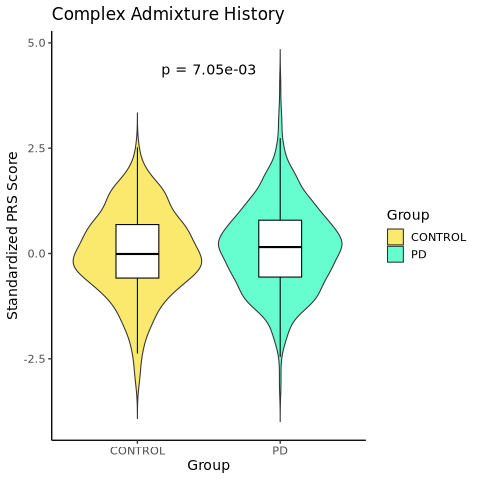

In [50]:
%%R
# Filter ancestry
cah_data <- data %>% filter(ANCESTRY == "CAH")

# Make sure disease/control labels are correct
# Assuming PHENO = 1 for Control, 2 for Disease
cah_data$Group <- ifelse(cah_data$PHENO == 1, "CONTROL", "PD")

# Example: your actual p-value
pval_text <- "7.05e-03" 

# Format it in scientific notation
# pval_text <- formatC(pval, format = "e", digits = 2)
# pval_text <- formatC(pval, format = "f", digits = 3)

# Violin plot
p <- ggplot(cah_data, aes(x = Group, y = PRS, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.6) +
  geom_boxplot(width = 0.3, outlier.shape = NA, 
               fill = "white", color = "black", alpha = 1) +
  scale_fill_manual(values = c("CONTROL" = "#F7DB0D", "PD" = "#00FDAD")) +
  theme_classic(base_size = 14) +
  labs(x = "Group", y = "Standardized PRS Score", title = "Complex Admixture History") +
  annotate("text",
         x = 1.5,
         y = max(cah_data$PRS, na.rm = TRUE) + 0.3,
         label = paste0("p = ", pval_text),
         size = 5)

print(p)

In [51]:
%%R

# Save plot
ggsave("/home/jupyter/workspace/ws_files/results/Violinplot/CAH.png",
       plot = p, width = 6, height = 5, dpi = 300)